In [2]:
import numpy as np  
import matplotlib.pyplot as plt  
import matplotlib.patches as mpatches
import pandas as pd  
import geopandas as gpd  
from shapely.geometry import Point  
import seaborn as sns  


import os  
import zipfile  
import tempfile 
import requests  

In [3]:


parks_area = gpd.read_file(
    "GSENM.kmz"
) 

protectedlands = gpd.read_file(
    "Protected Lands/PADUS4_1Designation_StateUT.kmz"
)

plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Nimbus Roman"]
ne_rivers_url = (
    "https://naciscdn.org/naturalearth/50m/physical/ne_50m_rivers_lake_centerlines.zip"
)
rivers_temp_dir = tempfile.mkdtemp()
rivers_zip_path = os.path.join(
    rivers_temp_dir, "ne_rivers.zip"
)
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}
response_rivers = requests.get(
    ne_rivers_url, headers=headers, stream=True
)
response_rivers.raise_for_status()  
with open(rivers_zip_path, "wb") as f:
    for chunk in response_rivers.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(rivers_zip_path, "r") as zip_ref:
    zip_ref.extractall(rivers_temp_dir)
rivers_shp_file = [f for f in os.listdir(rivers_temp_dir) if f.endswith(".shp")][
    0
]  
rivers = gpd.read_file(
    os.path.join(rivers_temp_dir, rivers_shp_file)
)  



ne_countries_url = (
    "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
)
countries_temp_dir = tempfile.mkdtemp()
countries_zip_path = os.path.join(
    countries_temp_dir, "ne_countries.zip" 
)     
response_countries = requests.get(
    ne_countries_url, headers=headers, stream=True
) 
response_countries.raise_for_status()
with open(countries_zip_path, "wb") as f:
    for chunk in response_countries.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(countries_zip_path, "r") as zip_ref:
    zip_ref.extractall(countries_temp_dir)
countries_shp_file = [f for f in os.listdir(countries_temp_dir) if f.endswith(".shp")][
    0
]
countries = gpd.read_file(
    os.path.join(countries_temp_dir, countries_shp_file)
)

state_borders_url = (
    "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip"
)
state_borders_temp_dir = tempfile.mkdtemp()
state_borders_zip_path = os.path.join(
    state_borders_temp_dir, "state_borders.zip"
)
response_state_borders = requests.get(
    state_borders_url, headers=headers, stream=True
)
response_state_borders.raise_for_status()
with open(state_borders_zip_path, "wb") as f:
    for chunk in response_state_borders.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(state_borders_zip_path, "r") as zip_ref:
    zip_ref.extractall(state_borders_temp_dir)
state_borders_shp_file = [
    f for f in os.listdir(state_borders_temp_dir) if f.endswith(".shp")
][0]
state_borders = gpd.read_file(
    os.path.join(state_borders_temp_dir, state_borders_shp_file)
)

oceans_url = (
    "https://naciscdn.org/naturalearth/10m/physical/ne_10m_ocean.zip"
)
oceans_temp_dir = tempfile.mkdtemp()
oceans_zip_path = os.path.join(
    oceans_temp_dir, "ne_ocean.zip"
)
response_oceans = requests.get(
    oceans_url, headers=headers, stream=True
)
response_oceans.raise_for_status()
with open(oceans_zip_path, "wb") as f:
    for chunk in response_oceans.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(oceans_zip_path, "r") as zip_ref:
    zip_ref.extractall(oceans_temp_dir)
oceans_shp_file = [f for f in os.listdir(oceans_temp_dir) if f.endswith(".shp")][
    0
]
oceans = gpd.read_file(
    os.path.join(oceans_temp_dir, oceans_shp_file)
)

ne_lakes_url = (
    "https://naciscdn.org/naturalearth/10m/physical/ne_10m_lakes.zip"
)
lakes_temp_dir = tempfile.mkdtemp()
lakes_zip_path = os.path.join(
    lakes_temp_dir, "ne_lakes.zip"
)  # we make a temporary directory to store the zip file with the lake locations    
response_lakes = requests.get(
    ne_lakes_url, headers=headers, stream=True
)  # we download the zip file
response_lakes.raise_for_status()  # check that the download was successful
with open(lakes_zip_path, "wb") as f:
    for chunk in response_lakes.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(lakes_zip_path, "r") as zip_ref:
    zip_ref.extractall(lakes_temp_dir)
lakes_shp_file = [f for f in os.listdir(lakes_temp_dir) if f.endswith(".shp")][
    0
]  # now find the lakes shapefile from the temporary directory
lakes = gpd.read_file(
    os.path.join(lakes_temp_dir, lakes_shp_file)
)  # read the lakes shapefile

ne_parks_url = (
    "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_parks_and_protected_lands.zip"
)
parks_temp_dir = tempfile.mkdtemp()
parks_zip_path = os.path.join(
    parks_temp_dir, "ne_parks.zip"
)  # we make a temporary directory to store the zip file with the park locations    
response_parks = requests.get(  
    ne_parks_url, headers=headers, stream=True
)  # we download the zip file
response_parks.raise_for_status()  # check that the download was successful
with open(parks_zip_path, "wb") as f:
    for chunk in response_parks.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(parks_zip_path, "r") as zip_ref:
    zip_ref.extractall(parks_temp_dir)
parks_shp_file = [f for f in os.listdir(parks_temp_dir) if f.endswith(".shp")][
    0
]  # now find the parks shapefile from the temporary directory
parks = gpd.read_file(
    os.path.join(parks_temp_dir, parks_shp_file)
)  # read the parks shapefile

# let's do the same exercise for state boundaries, so we can plot the location of Utah
# Download Natural Earth 110m admin level 1 (states/provinces) boundaries
ne_states_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip"
temp_dir = tempfile.mkdtemp()
zip_path = os.path.join(temp_dir, "ne_states.zip")
response = requests.get(
    ne_states_url, headers=headers, stream=True
)  # note we're using the same header we already defined when getting the rivers shapefile
response.raise_for_status()
with open(zip_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(temp_dir)
states_shp_file = [f for f in os.listdir(temp_dir) if f.endswith(".shp")][0]
states = gpd.read_file(os.path.join(temp_dir, states_shp_file))

kaiparowits = gpd.GeoDataFrame(
    {"geometry": [Point(-111.6, 37.5)]}, crs=states.crs
)


"""
straight_cliffs = gpd.GeoDataFrame(
    {"geometry": [Point(-112.522349, 37.5)]}, crs=states.crs
)  # adding point at Straight Cliffs's lat and lon
"""

'\nstraight_cliffs = gpd.GeoDataFrame(\n    {"geometry": [Point(-112.522349, 37.5)]}, crs=states.crs\n)  # adding point at Straight Cliffs\'s lat and lon\n'

/var/folders/cn/w96jhnkd6qsfv0xyljd8l2540000gn/T/ipykernel_28651/166028764.py:53: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax1.legend(


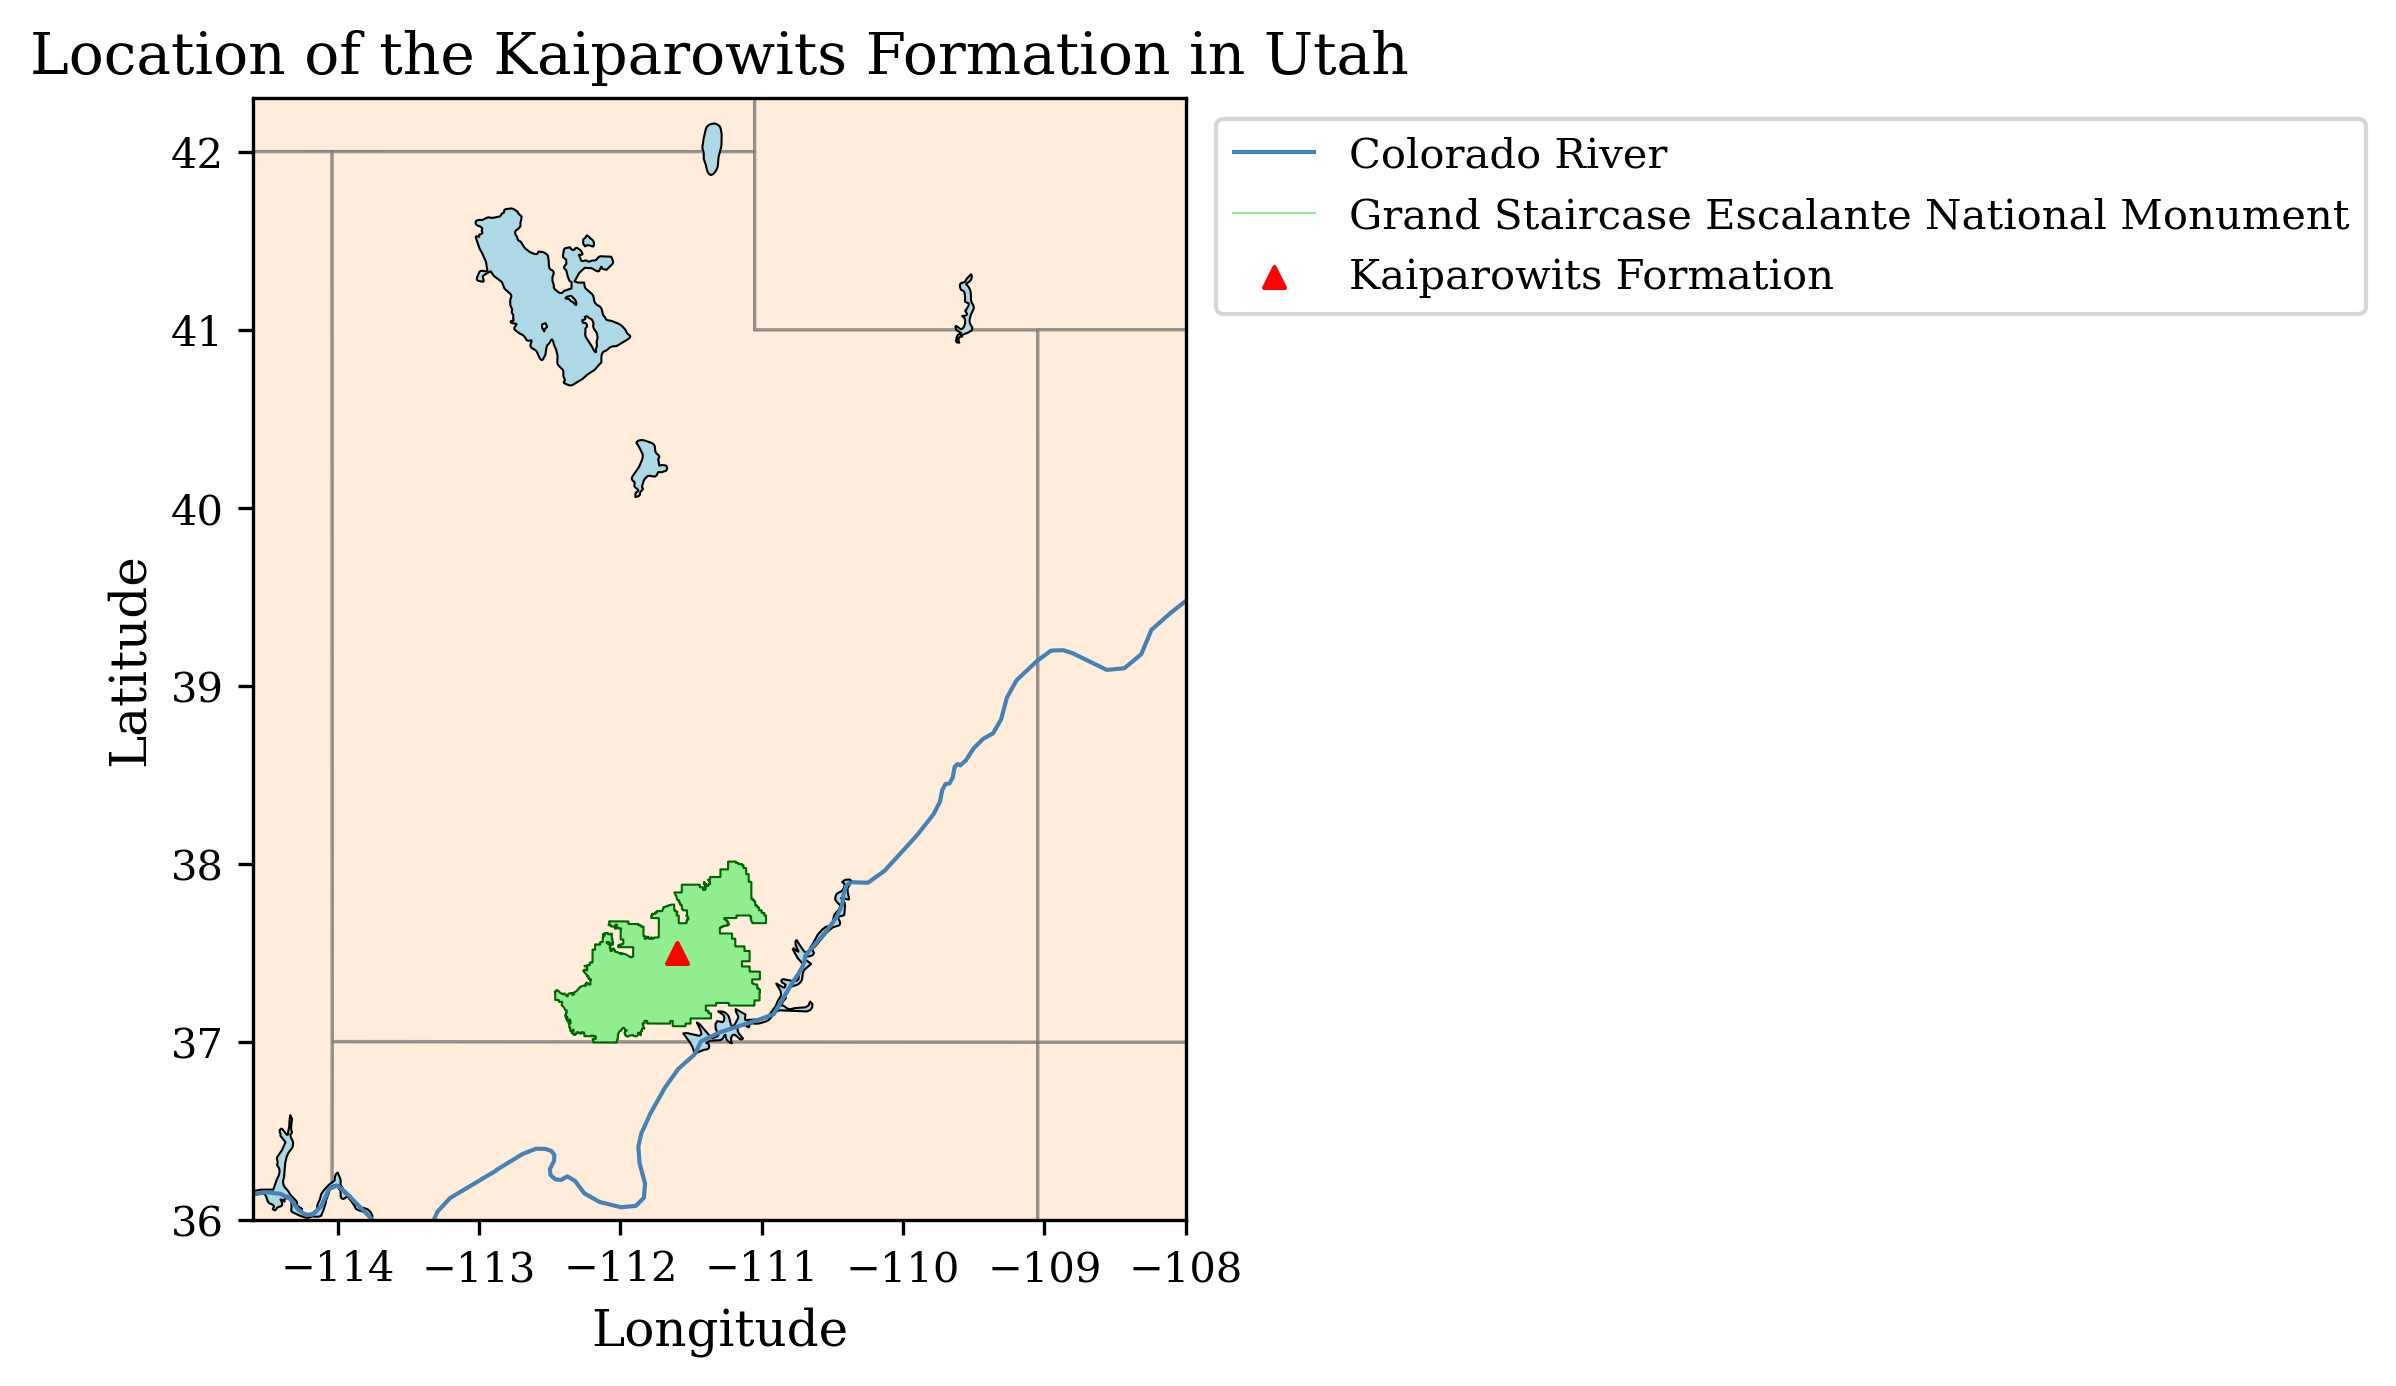

In [4]:
# we're finally ready to plot!
# let's begin by plotting the state boundaries
fig1 = plt.figure(
    dpi=300
)  # I'm making a high resolution figure, dpi=300, which is acceptable for printing and adding to presentations
ax1 = fig1.add_subplot(
    111
)  # let's add a single axis to the figure to plot all data together



# without this cropping step, the figure would show the entire United States, global large rivers, and all faults in the US.
ax1.set_xlim(
    -114.6, -108.0
)  # Utah center approximately: -111.5 longitude, 39.5 latitude
ax1.set_ylim(36, 42.3)

# plotting time!
states.plot(
    ax=ax1, edgecolor="dimgray", facecolor="peachpuff", linewidth=0.8, alpha=0.5
)  # let's plot the state boundaries in gray, with the state backgrounds in light orange

rivers.plot(
    ax=ax1, color="steelblue", linewidth=1, label="Colorado River"
)  # let's plot the rivers in a nice blue color

lakes.plot(
    ax=ax1, color="lightblue", edgecolor="black", linewidth=0.5, label="Lakes"
)

parks.plot(
    ax=ax1, color="lightgreen", edgecolor="darkgreen", linewidth=0.5, label="Grand Staircase Escalante National Monument"
)

parks_area.plot(
    ax=ax1, color="lightgreen", edgecolor="darkgreen", linewidth=0.5, label="Parks and Protected Lands"
)   

# let's plot them
kaiparowits.plot(
    ax=ax1, color="red", markersize=25, marker="^", label="Kaiparowits Formation"
)

"""
straight_cliffs.plot(
    ax=ax1, color="darkred", markersize=25, marker="^", label="Straight Cliffs Formation"
)
"""

# Add labels and legend
ax1.set_xlabel("Longitude", fontsize=12)
ax1.set_ylabel("Latitude", fontsize=12)
ax1.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True
)

plt.title("Location of the Kaiparowits Formation in Utah", fontsize=14)
'''
plt.text(
    -111.5, 37.6, "Unnamed Caiman Relative", fontsize=5, fontweight="bold", color="darkred"
)  # adding a text label for Utah

'''
plt.grid(False)
#plt.title("Locations of Allagatoroid Producing Formations in Utah", fontsize=14)
plt.tight_layout()  # this helps with the spacing of the plot elements
plt.show()  # show the plot!
# plt.savefig('utah_rivers_faults.png',bbox_inches='tight') # save the plot as a png file, takes other formats (e.g., pdf), bbox_inches='tight' removes extra whitespace and ensures your entire figure fits in the saved doc!

/var/folders/cn/w96jhnkd6qsfv0xyljd8l2540000gn/T/ipykernel_28651/4078169395.py:28: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(


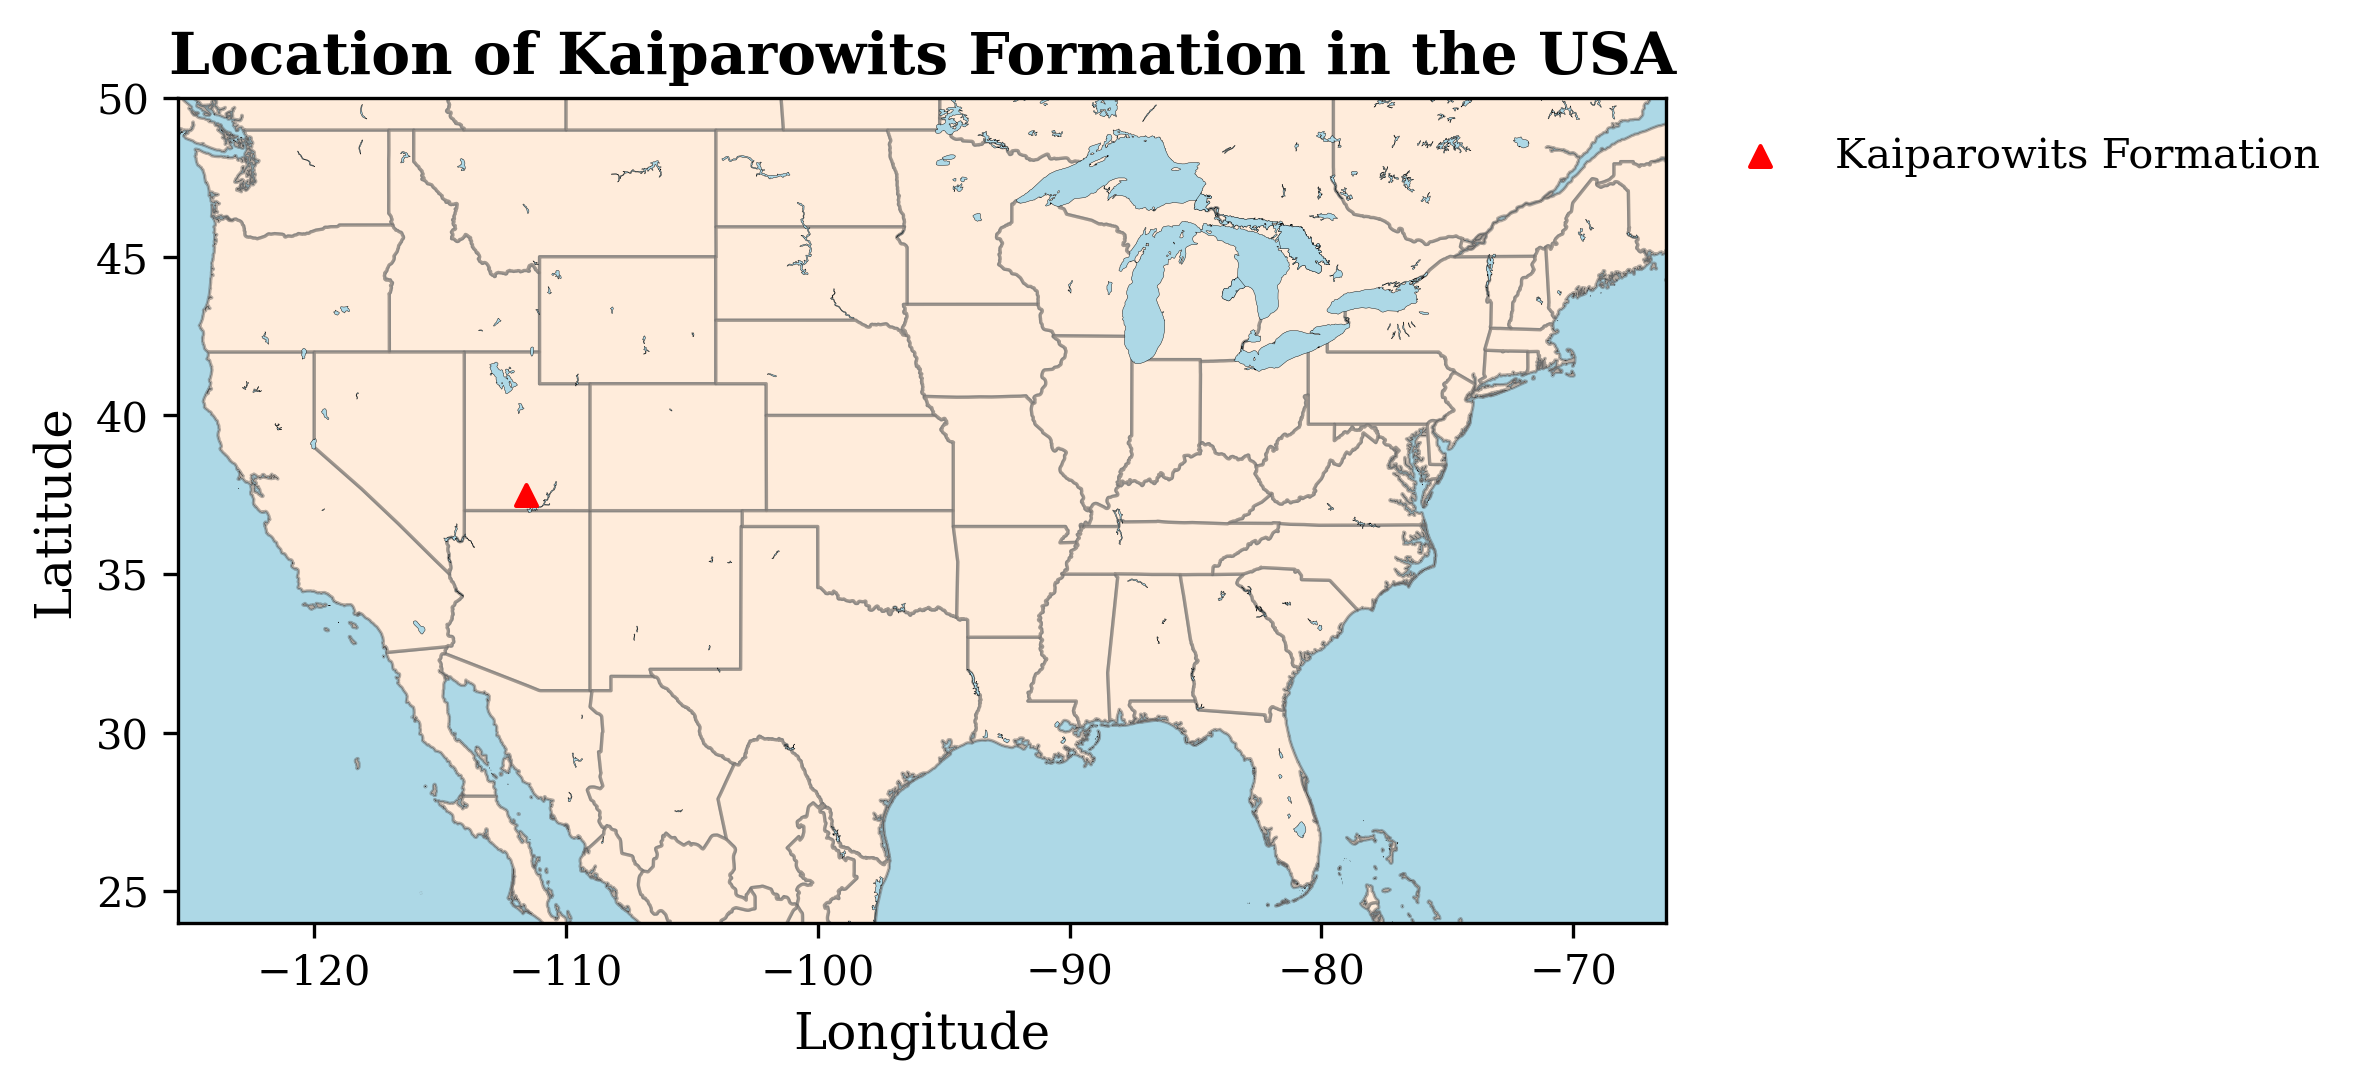

In [5]:
fig2 = plt.figure(
    dpi=300
)

ax2 = fig2.add_subplot(
    111
)

ax2.set_ylim(24,50)
ax2.set_xlim(-125.4,-66.3)

oceans.plot(
    ax=ax2, color="lightblue", edgecolor="black", linewidth=0.1, label="Oceans"
)

states.plot(
    ax=ax2, edgecolor="dimgray", facecolor="peachpuff", linewidth=0.8, alpha=0.5
) 

lakes.plot(
    ax=ax2, color="lightblue", edgecolor="black", linewidth=0.1, label="Lakes" 
)

kaiparowits.plot(
    ax=ax2, color="red", markersize=25, marker="^", label="Kaiparowits Formation"
)

plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False
)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.title("Location of Kaiparowits Formation in the USA", fontsize=14, fontdict={"weight": "bold"})
plt.show()

/var/folders/cn/w96jhnkd6qsfv0xyljd8l2540000gn/T/ipykernel_28651/4165669707.py:28: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(


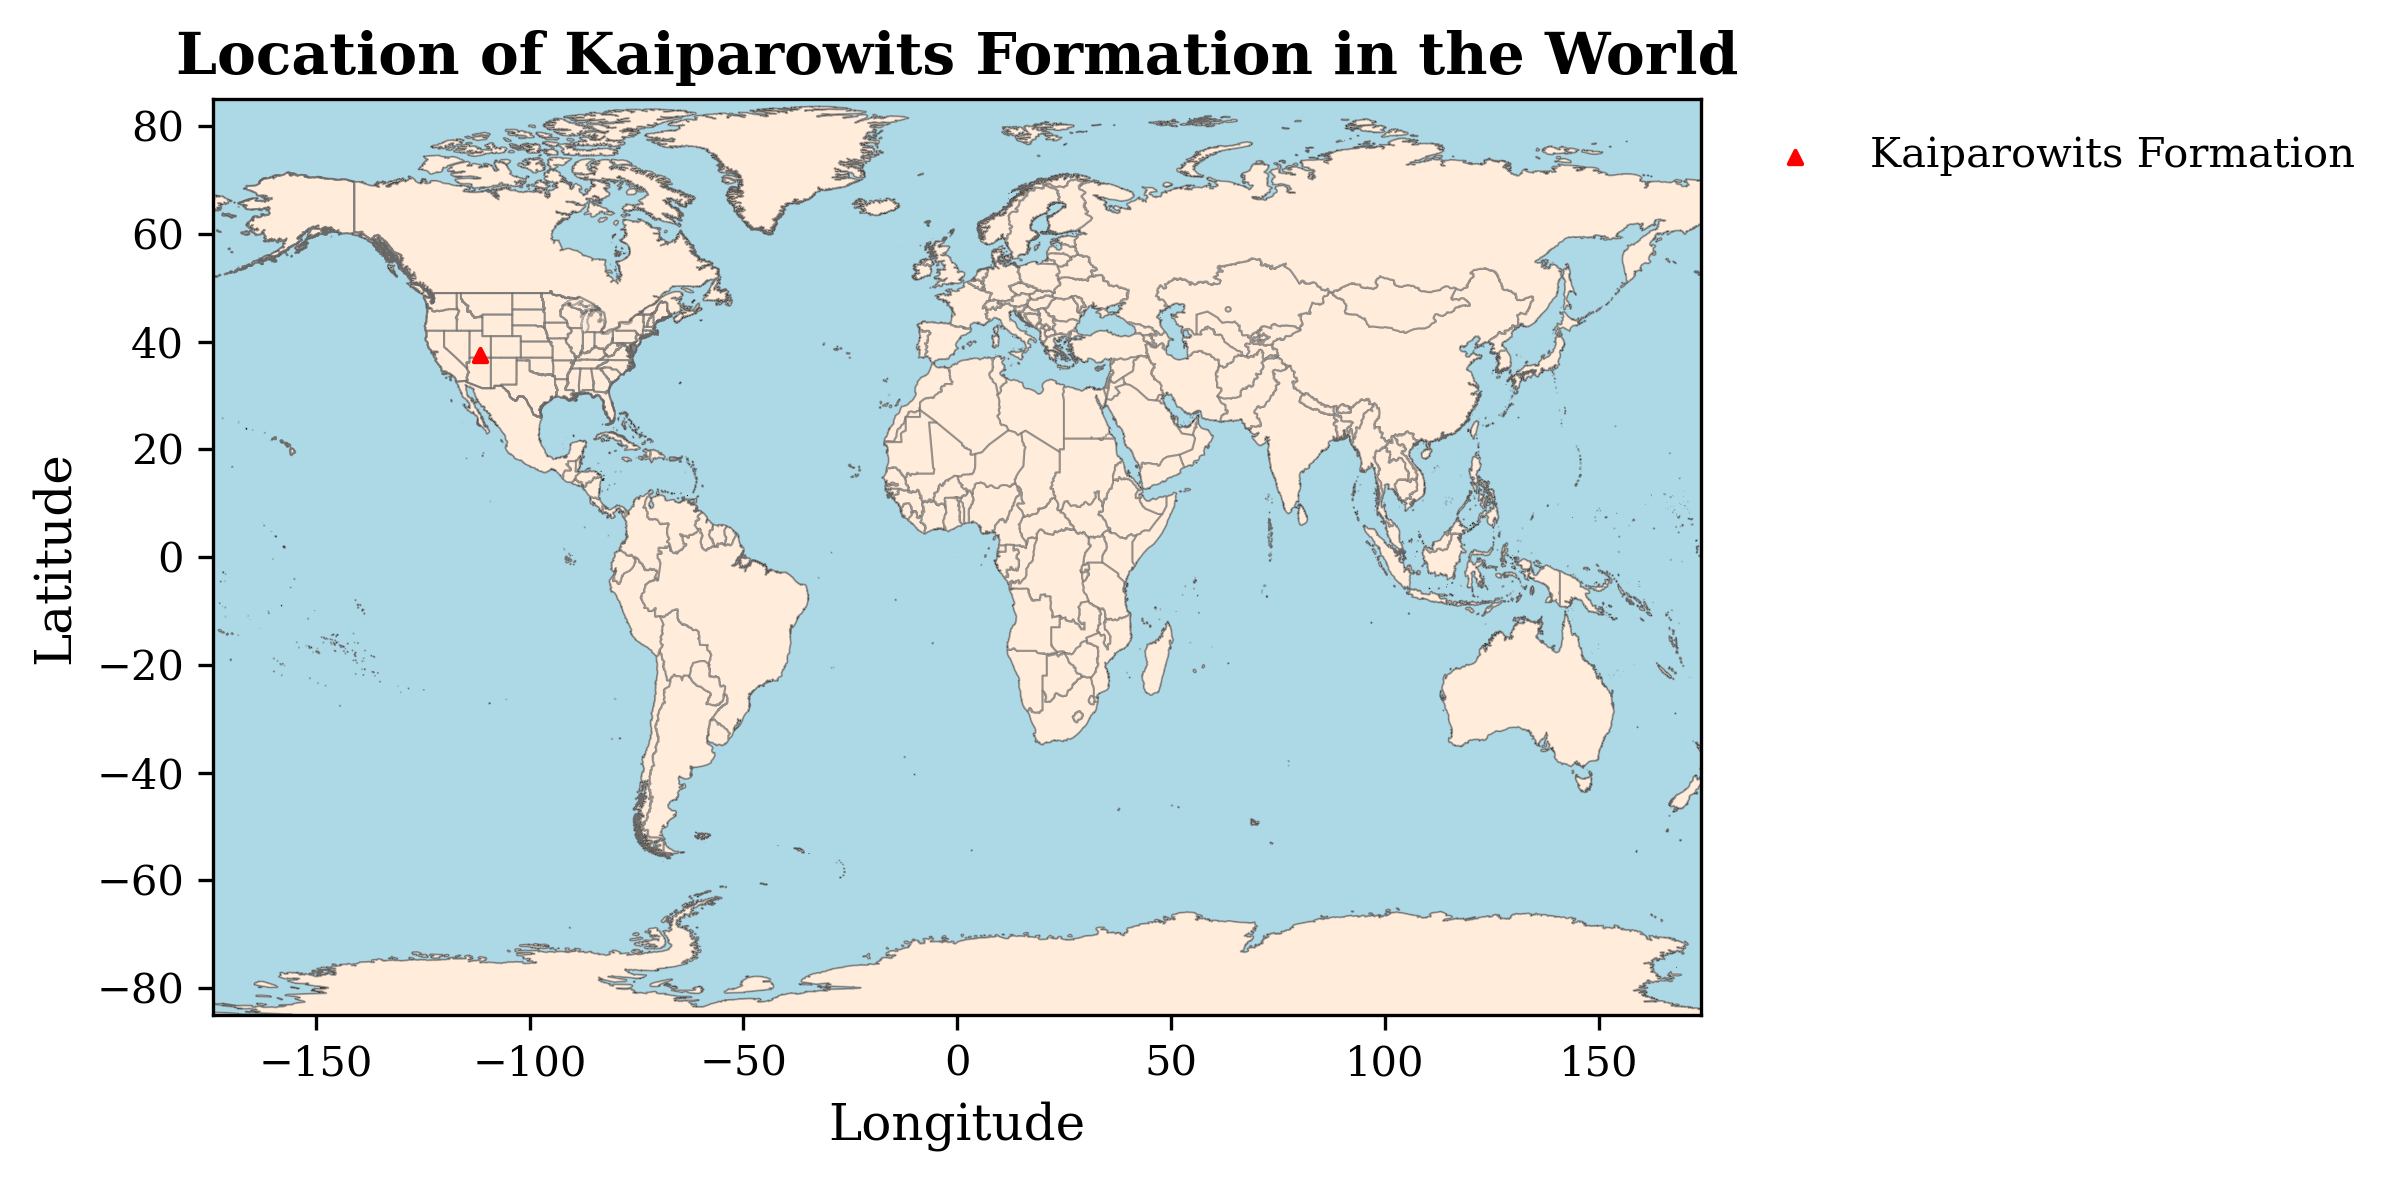

In [8]:
fig3 = plt.figure(
    dpi=300
)

ax3 = fig3.add_subplot(
    111
)

ax3.set_ylim(-85,85)
ax3.set_xlim(-174,174)

oceans.plot(
    ax=ax3, color="lightblue", edgecolor="black", linewidth=0.1, label="Oceans"
)

countries.plot(
    ax=ax3, edgecolor="dimgray", facecolor="peachpuff", linewidth=0.5, alpha=0.5
)

state_borders.plot(
    ax=ax3, edgecolor="dimgray", facecolor="none", linewidth=0.5, alpha=0.5
)

kaiparowits.plot(
    ax=ax3, color="red", markersize=10, marker="^", label="Kaiparowits Formation"
)

plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False
)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.title("Location of Kaiparowits Formation in the World", fontsize=14, fontdict={"weight": "bold"})
plt.show()
#plt.savefig('kaiparowitsfm3.png') # save the plot as a png file, takes other formats (e.g., pdf), bbox_inches='tight' removes extra whitespace and ensures your entire figure fits in the saved doc!

/var/folders/cn/w96jhnkd6qsfv0xyljd8l2540000gn/T/ipykernel_28651/3402444380.py:54: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax1.legend(
/var/folders/cn/w96jhnkd6qsfv0xyljd8l2540000gn/T/ipykernel_28651/3402444380.py:98: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(
/var/folders/cn/w96jhnkd6qsfv0xyljd8l2540000gn/T/ipykernel_28651/3402444380.py:135: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(


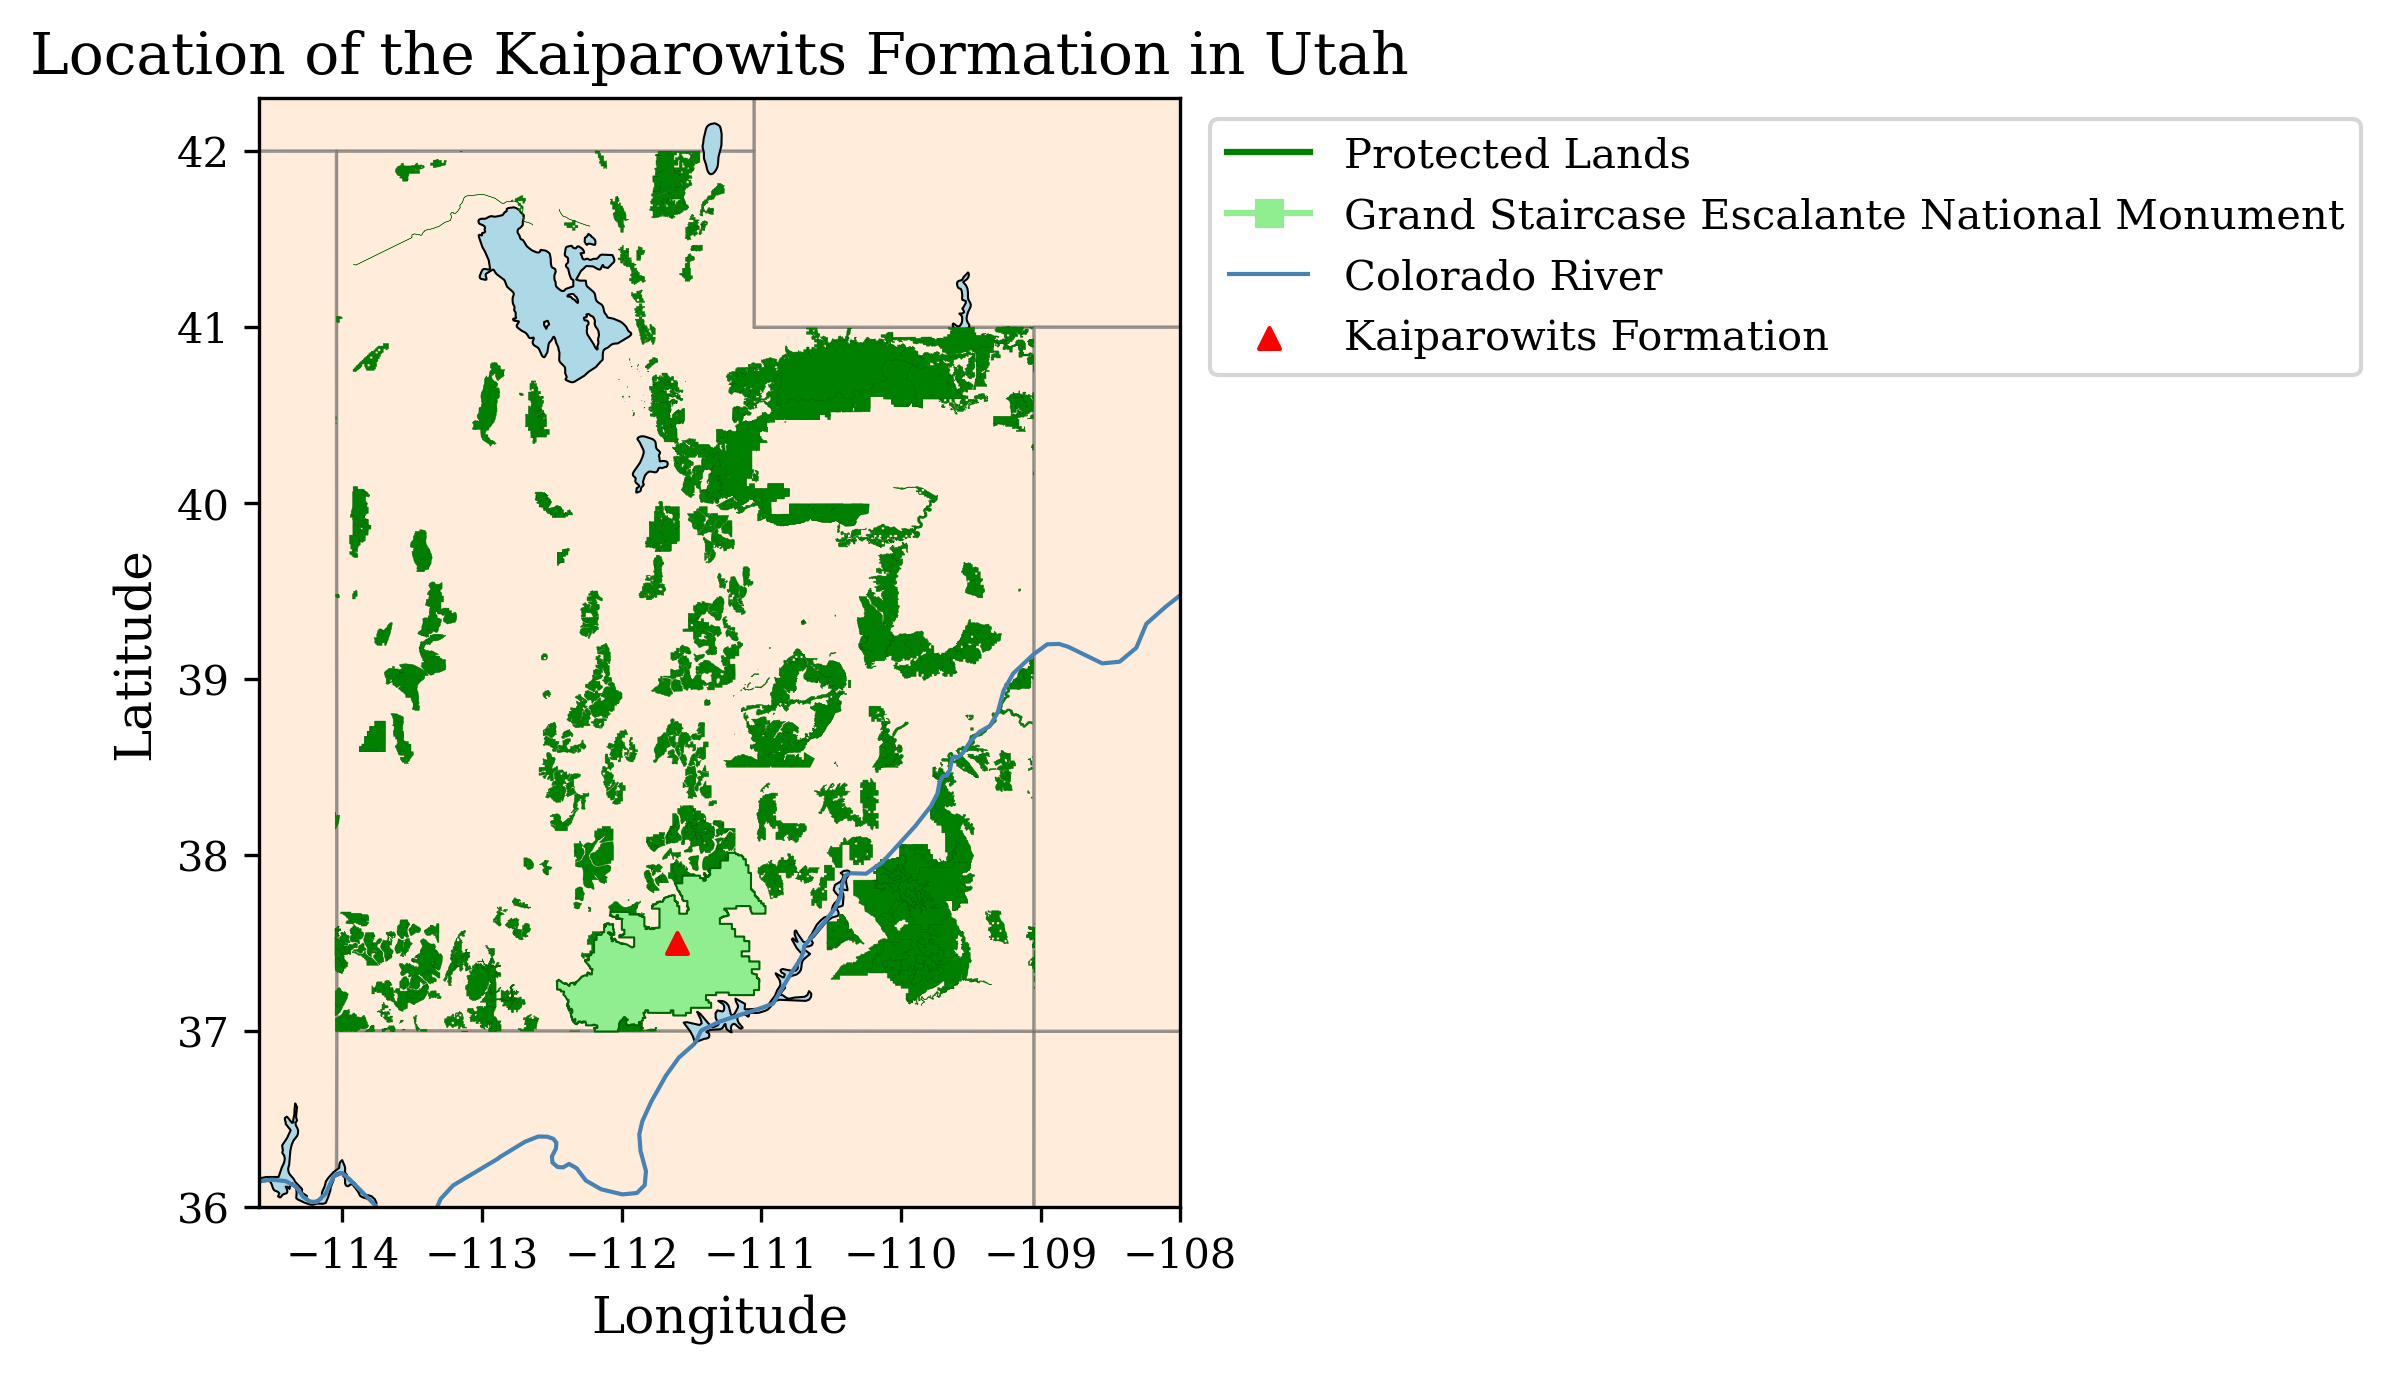

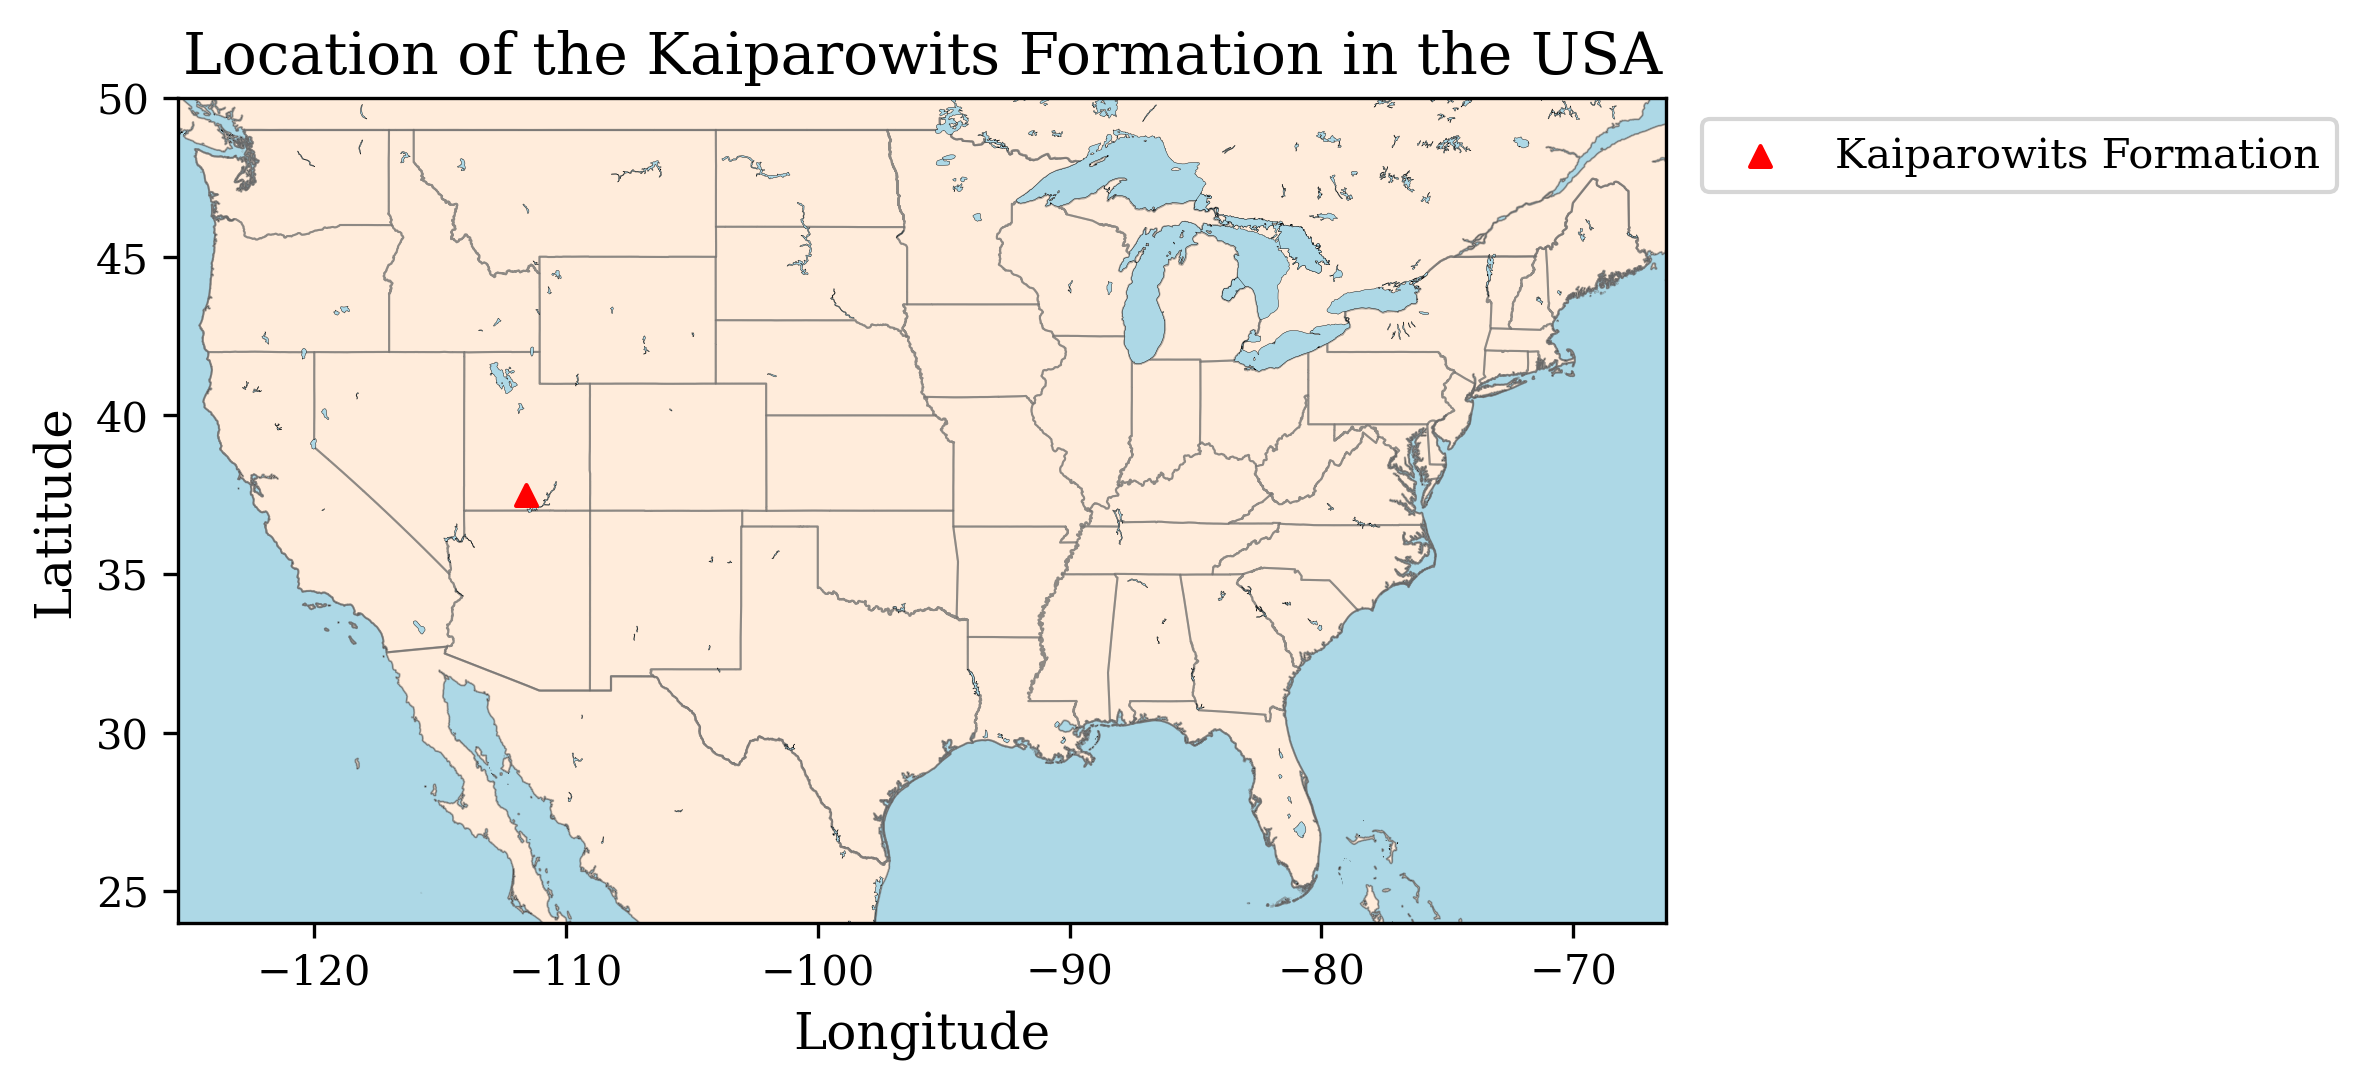

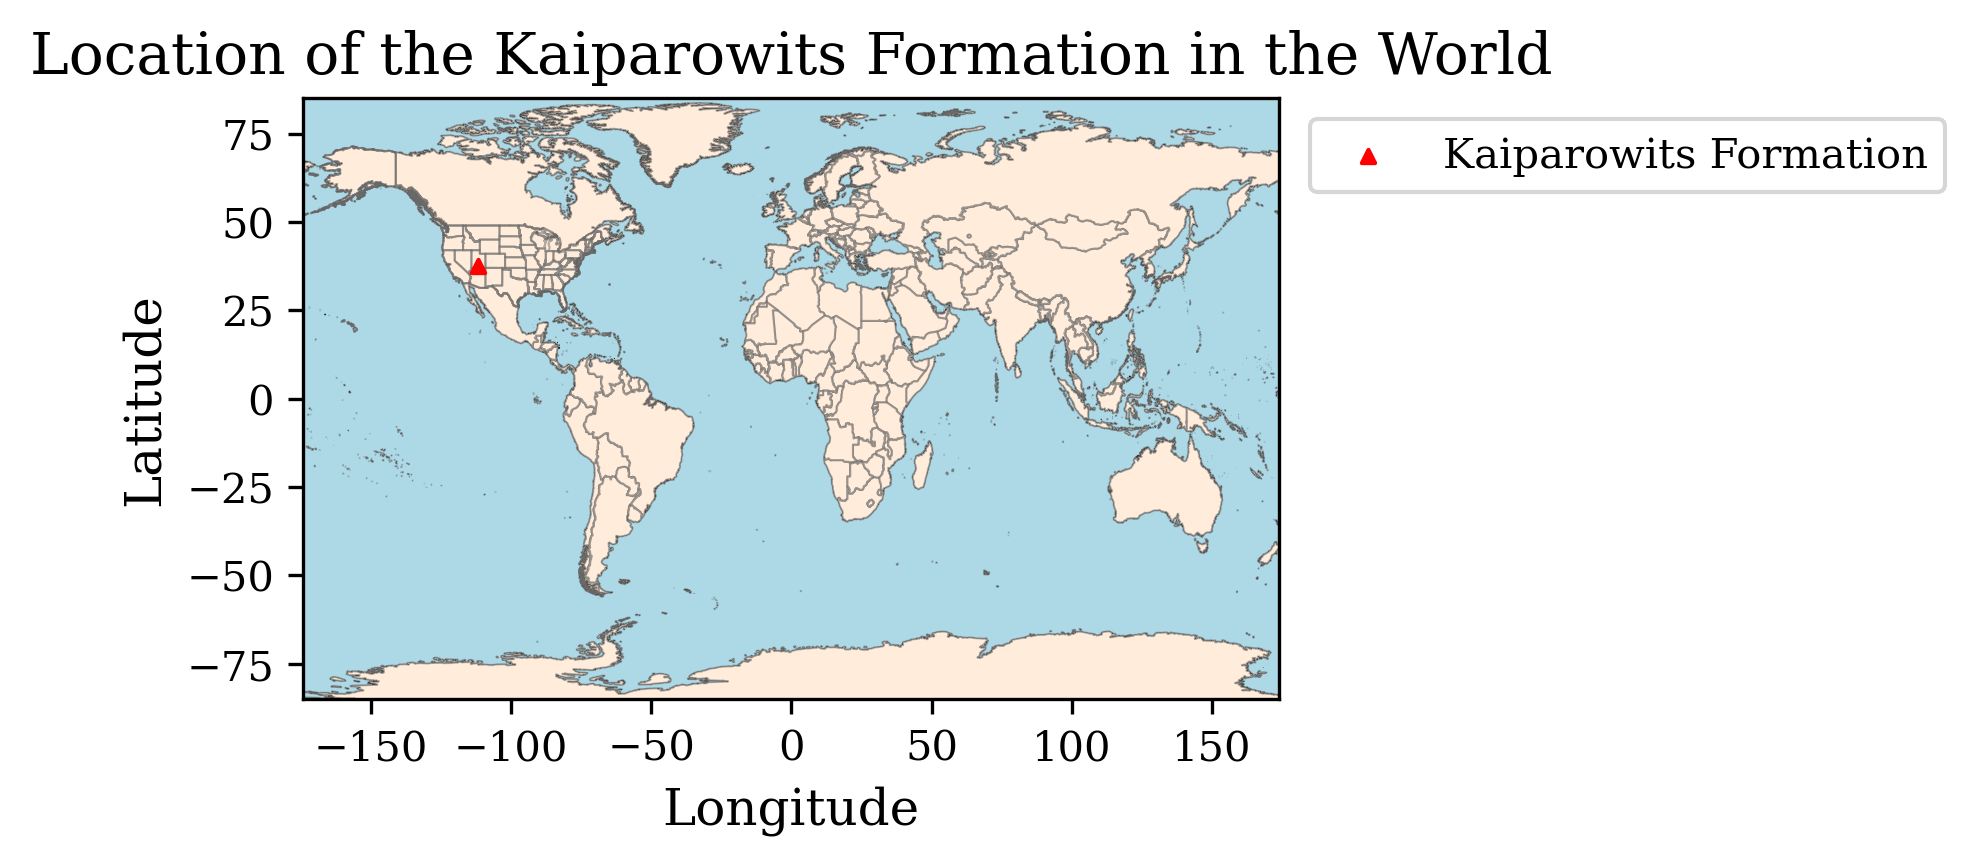

In [9]:
#FIGURES
fig1 = plt.figure(
    dpi=300
)
ax1 = fig1.add_subplot(
    111
)


ax1.set_xlim(
    -114.6, -108.0
)
ax1.set_ylim(36, 42.3)

#PLOTS
plt.plot(np.nan, np.nan, color='green', marker=None, label='Protected Lands')
plt.plot(np.nan, np.nan, color='lightgreen', marker="s", label='Grand Staircase Escalante National Monument')
states.plot(
    ax=ax1, edgecolor="dimgray", facecolor="peachpuff", linewidth=0.8, alpha=0.5
)

rivers.plot(
    ax=ax1, color="steelblue", linewidth=1, label="Colorado River"
)

lakes.plot(
    ax=ax1, color="lightblue", edgecolor="black", linewidth=0.5, label="Lakes"
)

protectedlands.plot(
    ax=ax1, color="green", edgecolor="darkgreen", marker="--", linewidth=0.1, label="Other Protected Lands"
)
"""
parks.plot(
    ax=ax1, color="lightgreen", edgecolor="darkgreen", linewidth=0.5, label="Grand Staircase Escalante National Monument"
)
"""
parks_area.plot(
    ax=ax1, color="lightgreen", edgecolor="darkgreen", linewidth=0.5, label=""
)   

kaiparowits.plot(
    ax=ax1, color="red", markersize=25, marker="^", label="Kaiparowits Formation"
)

"""
straight_cliffs.plot(
    ax=ax1, color="darkred", markersize=25, marker="^", label="Straight Cliffs Formation"
)
"""
#FINALE
ax1.set_xlabel("Longitude", fontsize=12)
ax1.set_ylabel("Latitude", fontsize=12)
ax1.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True
)

plt.title("Location of the Kaiparowits Formation in Utah", fontsize=14)
'''
plt.text(
    -111.5, 37.6, "Unnamed Caiman Relative", fontsize=5, fontweight="bold", color="darkred"
)  # adding a text label for Utah

'''
plt.savefig('kaiparowitsfm.png',bbox_inches='tight')

#FIGURE 2
fig2 = plt.figure(
    dpi=300
)

ax2 = fig2.add_subplot(
    111
)

ax2.set_ylim(24,50)
ax2.set_xlim(-125.4,-66.3)

oceans.plot(
    ax=ax2, color="lightblue", edgecolor="black", linewidth=0.1, label="Oceans"
)
countries.plot(
    ax=ax2, edgecolor="dimgray", facecolor="peachpuff", linewidth=0.5, alpha=0.5
)

state_borders.plot(
    ax=ax2, edgecolor="dimgray", facecolor="none", linewidth=0.5, alpha=0.5
)

lakes.plot(
    ax=ax2, color="lightblue", edgecolor="black", linewidth=0.1, label="Lakes" 
)

kaiparowits.plot(
    ax=ax2, color="red", markersize=25, marker="^", label="Kaiparowits Formation"
)

plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True
)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.title("Location of the Kaiparowits Formation in the USA", fontsize=14)
plt.savefig('kaiparowitsfm1.png',bbox_inches='tight')

#FIGURE 3

fig3 = plt.figure(
    dpi=300
)

ax3 = fig3.add_subplot(
    111
)

ax3.set_ylim(-85,85)
ax3.set_xlim(-174,174)

oceans.plot(
    ax=ax3, color="lightblue", edgecolor="black", linewidth=0.1, label="Oceans"
)

countries.plot(
    ax=ax3, edgecolor="dimgray", facecolor="peachpuff", linewidth=0.5, alpha=0.5
)

state_borders.plot(
    ax=ax3, edgecolor="dimgray", facecolor="none", linewidth=0.5, alpha=0.5
)

kaiparowits.plot(
    ax=ax3, color="red", markersize=10, marker="^", label="Kaiparowits Formation"
)

plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True
)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.title("Location of the Kaiparowits Formation in the World", fontsize=14)


plt.grid(False)
#plt.title("Locations of Allagatoroid Producing Formations in Utah", fontsize=14)
plt.tight_layout()  # this helps with the spacing of the plot elements
plt.savefig('kaiparowitsfm2.png',bbox_inches='tight')
plt.show()  # show the plot!